In [1]:
import numpy as np
import matplotlib.pyplot as plt
from thinkdsp import Wave, read_wave

Упражнение 11.3

In [3]:
def downsample_signal(wave, factor):
    new_length = len(wave) // factor
    sampled_ys = wave.ys[::factor][:new_length]
    new_framerate = wave.framerate // factor
    return Wave(sampled_ys, framerate=new_framerate)

In [4]:
def upsample_wave(wave, target_framerate):
    from scipy import signal
    current_framerate = wave.framerate
    num_samples = int(len(wave.ys) * target_framerate / current_framerate)
    upsampled_ys = signal.resample(wave.ys, num_samples)
    return Wave(upsampled_ys, framerate=target_framerate)

In [5]:
drum_wave = read_wave('263868__kevcio__amen-break-a-160-bpm.wav')
drum_wave.normalize()

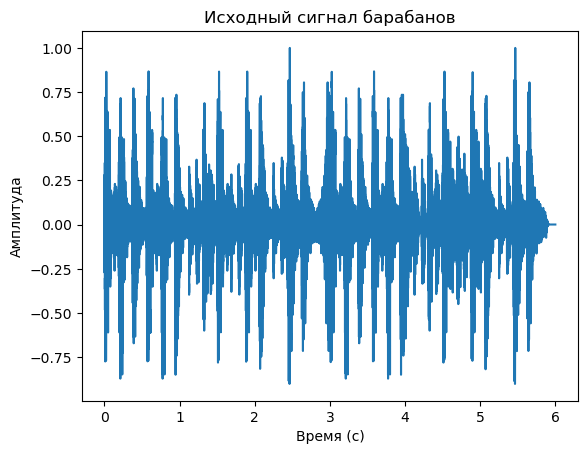

In [6]:
plt.plot(drum_wave.ts, drum_wave.ys)
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Исходный сигнал барабанов')
plt.show()

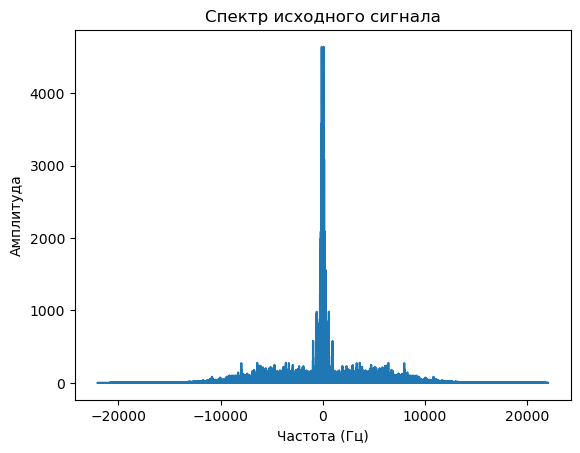

In [7]:
drum_spectrum = drum_wave.make_spectrum(full=True)
plt.plot(drum_spectrum.fs, drum_spectrum.amps)
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('Спектр исходного сигнала')
plt.show()

In [8]:
downsample_factor = 3
new_framerate = drum_wave.framerate // downsample_factor
cutoff_freq = new_framerate / 2 - 1
drum_spectrum.low_pass(cutoff_freq)

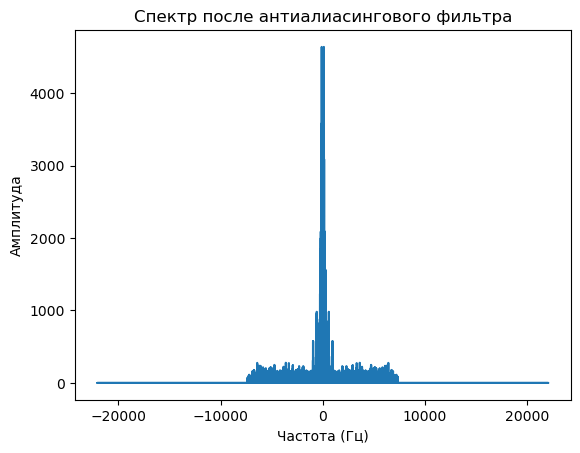

In [9]:
plt.plot(drum_spectrum.fs, drum_spectrum.amps)
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('Спектр после антиалиасингового фильтра')
plt.show()

In [10]:
filtered_wave = drum_spectrum.make_wave()
filtered_wave.normalize()

In [11]:
downsampled_wave = downsample_signal(filtered_wave, downsample_factor)
downsampled_wave.normalize()

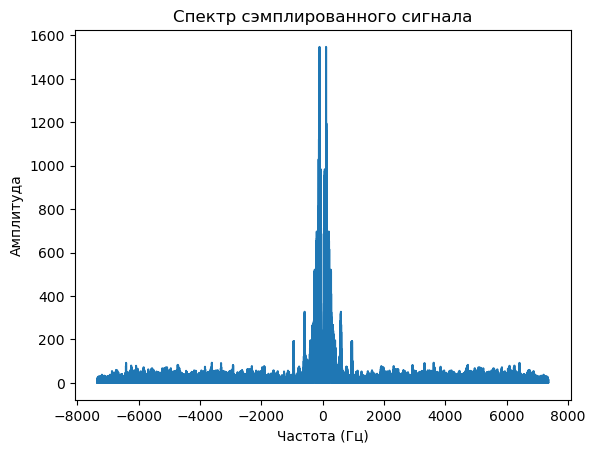

In [12]:
downsampled_spectrum = downsampled_wave.make_spectrum(full=True)
plt.plot(downsampled_spectrum.fs, downsampled_spectrum.amps)
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('Спектр сэмплированного сигнала')
plt.show()

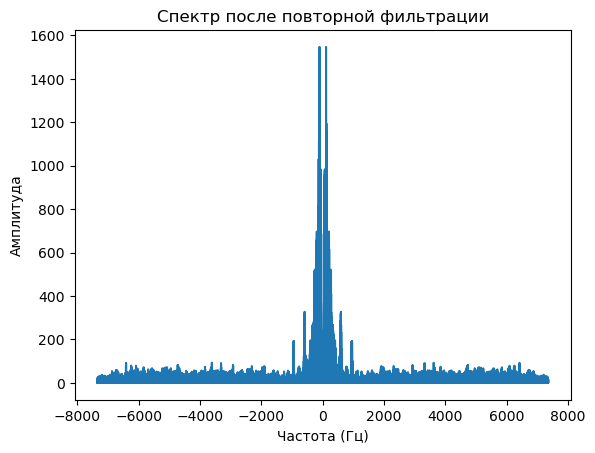

In [13]:
downsampled_spectrum.low_pass(cutoff_freq)
plt.plot(downsampled_spectrum.fs, downsampled_spectrum.amps)
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('Спектр после повторной фильтрации')
plt.show()

In [48]:
restored_wave = upsample_wave(downsampled_wave, drum_wave.framerate)
restored_spectrum = restored_wave.make_spectrum(full=True)
drum_spectrum_max = np.max(np.abs(drum_spectrum.hs))
restored_spectrum_max = np.max(np.abs(restored_spectrum.hs))
if drum_spectrum_max != 0 and restored_spectrum_max != 0:
    drum_spectrum.hs = drum_spectrum.hs / drum_spectrum_max
    restored_spectrum.hs = restored_spectrum.hs / restored_spectrum_max

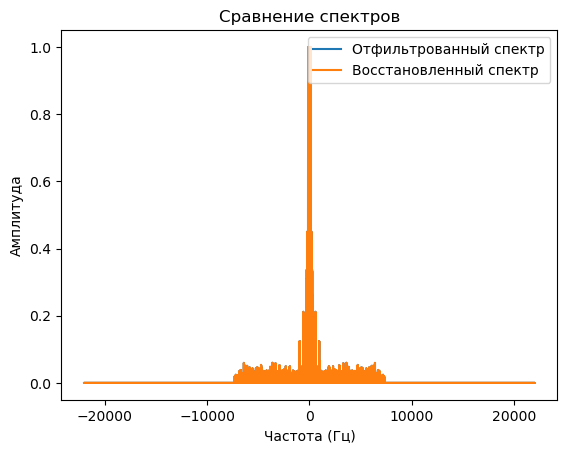

In [50]:
plt.plot(drum_spectrum.fs, drum_spectrum.amps, label='Отфильтрованный спектр')
plt.plot(restored_spectrum.fs, restored_spectrum.amps, label='Восстановленный спектр')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('Сравнение спектров')
plt.legend()
plt.show()

In [52]:
print(f"Длина drum_spectrum: {len(drum_spectrum.hs)}, Длина restored_spectrum: {len(restored_spectrum.hs)}")
print(f"Частота дискретизации drum_spectrum: {drum_spectrum.framerate}, restored_spectrum: {restored_spectrum.framerate}")

Длина drum_spectrum: 264600, Длина restored_spectrum: 264600
Частота дискретизации drum_spectrum: 44100, restored_spectrum: 44100


In [54]:
max_diff = drum_spectrum.max_diff(restored_spectrum)
print(f"Максимальная разница между спектрами: {max_diff}")

Максимальная разница между спектрами: 4.449557262054371e-16


In [18]:
restored_wave.normalize()

C:\Users\PC\anaconda3\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\PC\anaconda3\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


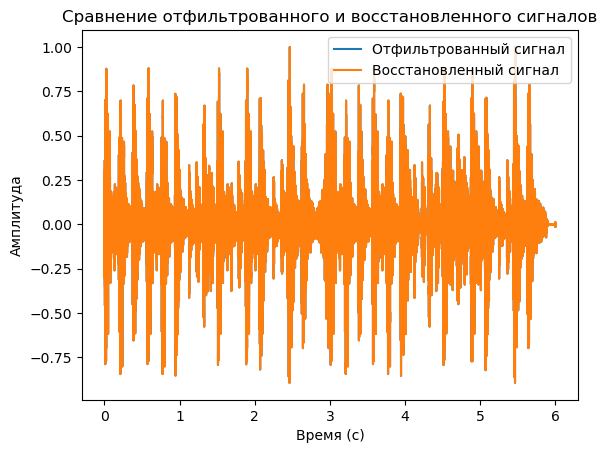

In [19]:
plt.plot(filtered_wave.ts, filtered_wave.ys, label='Отфильтрованный сигнал')
plt.plot(restored_wave.ts, restored_wave.ys, label='Восстановленный сигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Сравнение отфильтрованного и восстановленного сигналов')
plt.legend()
plt.show()